# Controller scenarios — tracking, holding & adapting

A **plug-and-play** test bench for the Week-3 control stack on the real Brain.

Pick a **controller** and an **estimator** in the config cell below, then run the
scenario cells. Every scenario drives the *same* `GG4.Brain` with the *same*
physically-anchored targets, so swapping the controller or the estimator is a
fair, one-line comparison.

**Scenarios**
1. **Track** a sinusoid (does it follow a moving reference?)
2. **Hold a feasible target** (a level the one-sided actuator *can* reach)
3. **Hold an infeasible target** (a level outside the reachable set — watch it saturate, not blow up)
4. **Adapt to a moving target** (the setpoint jumps half-way through)

**Two knobs**
- `CONTROLLER` — `OpenLoop`, `ProportionalFeedback`, `PI`, `LQG`, `LQGI`, `PolePlacement`, `MPC`, `OffsetFreeMPC`
- `ESTIMATOR` — `"true"` (the quarantined ground-truth yardstick) or `"em"` (the honest N4SID→EM fit from one noisy probe)

> Targets are always anchored in the **ground-truth** frame so the *same physical
> level* is requested no matter which estimator the controller uses internally —
> that's what makes "true vs EM" an apples-to-apples test.

> **Kernel:** run this with the project venv (`venv/`), which has `GG4` installed.
> The setup cell adds the venv `site-packages` to `sys.path` as a fallback.

## 1 · Config — the only cell you normally edit

In [1]:
# ============================ CONTROL PANEL ============================
CONTROLLER = "MPC"     # OpenLoop | ProportionalFeedback | PI | LQG | LQGI |
                       # PolePlacement | MPC | OffsetFreeMPC
ESTIMATOR  = "em"      # "true" = ground-truth yardstick | "em" = honest N4SID->EM fit
READOUT    = "pca"     # "pca" = 2-D population readout | "dominant" = 1-D sustainable direction

SEED   = 0             # Brain seed (ground-truth files exist for 0..4)
T_RUN  = 300           # closed-loop steps per scenario
T_CAL  = 1000          # probe length for the EM fit (only used when ESTIMATOR == "em")
# ======================================================================

## 2 · Setup — imports & the Brain factory

In [2]:
import sys, importlib.util
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# --- locate week3/ and make its packages importable ------------------
ROOT = Path.cwd()
if not (ROOT / "control").exists():          # be forgiving about cwd
    for p in [ROOT] + list(ROOT.parents):
        if (p / "control").exists() and p.name == "week3":
            ROOT = p; break
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT.parent / "week 1"))
# --- fallback: pull GG4 from the project venv if not already importable
if importlib.util.find_spec("GG4") is None:
    for sp in [ROOT.parent / "venv" / "Lib" / "site-packages",
               ROOT.parent / "venv" / "lib" / "site-packages"]:
        if sp.exists():
            sys.path.insert(0, str(sp)); break

from GG4 import Brain
from control.plant import BrainPlant
from control.observer import SteadyStateKalman
from control.controllers import (
    OpenLoop, ProportionalFeedback, PI, LQG, LQGI, PolePlacement, MPC, OffsetFreeMPC,
)
from control.closed_loop import run_closed_loop
from control.readouts import build_readout, auto_proportional_gain, auto_integral_gain
from control.reachability import steady_state_gain, zonotope_vertices
from estimator.identify import EstimatorNew
from analysis.ground_truth import GroundTruthModel
from viz.style import CONTROLLER_COLORS, style_axis

def brain_plant(seed):
    '''A fresh black-box Brain wrapped in the common plant surface.'''
    return BrainPlant(Brain(random_seed=int(seed)))

print(f"ROOT = {ROOT}")
print("setup OK")

ROOT = c:\Github\GG4\week3
setup OK


## 3 · Build the model(s)

We always load the **ground-truth** model (it anchors the targets and is the
`"true"` estimator option). When `ESTIMATOR == "em"` we additionally run the
honest pipeline: one noisy `Uniform[0,1]²` probe → N4SID warm-start → affine EM.

`build_model(which)` returns the `(A, B, C, Q, R, a, c)` dict that the controller
and observer consume — nothing else changes downstream.

In [3]:
# Ground truth (quarantined yardstick) — anchors targets, and is the "true" model.
gt = GroundTruthModel.load(ROOT / "results" / "ground_truth" / f"seed_{SEED}.npz")
TRUE = dict(A=gt.A, B=gt.B, C=gt.C, Q=gt.Q, R=gt.R, a=gt.a, c=gt.c)

# Honest probe (also used to build the PCA readout, which is model-free).
_rng = np.random.default_rng(42 + SEED)
U_cal = _rng.uniform(0.0, 1.0, size=(T_CAL, int(gt.B.shape[1])))
_pl = brain_plant(SEED)
p_obs = len(_pl.measure())
Y_cal = np.empty((T_CAL, p_obs))
_pl = brain_plant(SEED)
Y_cal[0] = _pl.measure(); _pl.next_state(U_cal[0])
for t in range(1, T_CAL):
    Y_cal[t] = _pl.measure(); _pl.next_state(U_cal[t])

_EM_CACHE = {}
def build_model(which):
    '''which in {"true","em"} -> dict(A,B,C,Q,R,a,c).'''
    if which == "true":
        return TRUE
    if which == "em":
        if "em" not in _EM_CACHE:
            est = EstimatorNew().fit(Y_cal, U_cal, n=6, init="n4sid",
                                     max_iter=80, tol=1e-5)
            _EM_CACHE["em"] = dict(A=est.A, B=est.B, C=est.C, Q=est.Q,
                                   R=est.R, a=est.a, c=est.c)
        return _EM_CACHE["em"]
    raise ValueError(f"unknown estimator {which!r}")

MODEL = build_model(ESTIMATOR)
rho = float(np.max(np.abs(np.linalg.eigvals(MODEL["A"]))))
print(f"controlling with the {ESTIMATOR!r} model   (rho(A) = {rho:.3f}, n = {MODEL['A'].shape[0]})")

controlling with the 'em' model   (rho(A) = 0.911, n = 6)


## 4 · Readout & physically-anchored targets

The **readout** `M` projects the 16-D measurement onto what we actually want to
control (`z = M y`). Targets are built in the **ground-truth** reachable set so
they mean the same physical level for every controller/estimator:

- **feasible**  — the centre of the reachable region (definitely holdable)
- **infeasible** — 2× past the farthest reachable corner (cannot be held)
- **sinusoid**  — oscillates inside the reachable region
- **moving**    — jumps between two feasible points half-way through `T_RUN`

In [4]:
# Readout M (PCA is model-free; "dominant" uses the ground-truth A,B,C).
if READOUT == "pca":
    M = build_readout("pca", Y_probe=Y_cal, k=2)
elif READOUT == "dominant":
    M = build_readout("dominant", A=gt.A, B=gt.B, C=gt.C)
else:
    raise ValueError(f"unknown readout {READOUT!r}")
q = M.shape[0]

# Reachable region in readout space, anchored in the ground-truth frame.
G_gt, z0_gt = steady_state_gain(gt.A, gt.B, gt.C, M, a=gt.a, c=gt.c)
V = zonotope_vertices(G_gt, z0_gt)        # (2^m, q) corners of the holdable set
center = V.mean(axis=0)
lo, hi = V.min(axis=0), V.max(axis=0)     # per-dim reachable interval
half = 0.5 * (hi - lo)

# farthest corner, then the corner farthest from that one -> a wide, feasible jump
_far = V[np.argmax(np.linalg.norm(V - center, axis=1))]
_far2 = V[np.argmax(np.linalg.norm(V - _far, axis=1))]

REF_FEASIBLE   = center.copy()
REF_INFEASIBLE = center + 2.0 * (_far - center)          # well outside the box
PT_A = center + 0.45 * (_far - center)                   # feasible move endpoints
PT_B = center + 0.45 * (_far2 - center)
SWITCH = T_RUN // 2

def ref_sinusoid(t):
    amp = 0.45 * half
    phase = 2 * np.pi * t / 80.0
    if q == 1:
        return center + amp * np.sin(phase)
    return center + amp * np.array([np.sin(phase), 0.6 * np.cos(phase)])

def ref_const(value):
    value = np.asarray(value, float)
    return lambda t: value

def ref_moving(t):
    return PT_A if t < SWITCH else PT_B

def feasible_interval(d):
    return float(lo[d]), float(hi[d])

print(f"readout '{READOUT}'  ->  q = {q}")
print(f"feasible (centre)  z* = {np.round(REF_FEASIBLE, 2)}")
print(f"infeasible         z* = {np.round(REF_INFEASIBLE, 2)}  (outside reachable set)")
print(f"moving: {np.round(PT_A,2)}  ->  {np.round(PT_B,2)}  at t = {SWITCH}")

readout 'pca'  ->  q = 2
feasible (centre)  z* = [19.98  0.45]
infeasible         z* = [65.86  2.13]  (outside reachable set)
moving: [30.3   0.83]  ->  [9.66 0.08]  at t = 150


## 5 · The engine — `make_controller`, `run`, `plot_scenario`

`make_controller` is the single place that maps a name to a configured
controller. Add or retune a controller here and every scenario picks it up.

In [5]:
def make_controller(name, model, M, ref):
    A, B, C, a, c = model["A"], model["B"], model["C"], model["a"], model["c"]
    m = B.shape[1]
    G_r, _ = steady_state_gain(A, B, C, M, a=a, c=c)
    if name == "OpenLoop":
        return OpenLoop(input_dim=m)
    if name == "ProportionalFeedback":
        return ProportionalFeedback(Kp=auto_proportional_gain(G_r, 0.3), M=M, ref=ref)
    if name == "PI":
        return PI(Kp=auto_proportional_gain(G_r, 0.3),
                  Ki=auto_integral_gain(G_r, 0.1), M=M, ref=ref, anti_windup=True)
    if name == "LQG":
        return LQG(A, B, C, M, a=a, c=c, rho=1.0, ref=ref)
    if name == "LQGI":
        return LQGI(A, B, C, M, a=a, c=c, rho=1.0, rho_q=0.01, ref=ref, anti_windup=True)
    if name == "PolePlacement":
        poles = np.linspace(0.55, 0.9, A.shape[0])
        return PolePlacement(A, B, C, M, target_poles=poles, a=a, c=c, ref=ref)
    if name == "MPC":
        return MPC(A, B, C, M, a=a, c=c, ref=ref)
    if name == "OffsetFreeMPC":
        return OffsetFreeMPC(A, B, C, M, a=a, c=c, ref=ref)
    raise ValueError(f"unknown controller {name!r}")

def run(model, name, M, ref_fn, T=None):
    '''Closed-loop on the real Brain. Returns the run_closed_loop log dict.'''
    T = T_RUN if T is None else T
    plant = brain_plant(SEED)
    obs = SteadyStateKalman(model["A"], model["B"], model["C"],
                            model["Q"], model["R"], a=model["a"], c=model["c"])
    ctrl = make_controller(name, model, M, ref_fn(0))
    return run_closed_loop(plant, ctrl, obs, T=T, ref_fn=ref_fn)

def ref_traj(ref_fn, T):
    s = np.asarray(ref_fn(0), float)
    out = np.empty((T,) + s.shape)
    for t in range(T):
        out[t] = np.asarray(ref_fn(t), float)
    return out

def ctrl_color(name):
    return CONTROLLER_COLORS.get(name, "tab:red")

In [6]:
def plot_scenario(logs, M, ref_fn, title, name,
                  shade_feasible=True, switch=None):
    '''Time series of every readout component (+ inputs, + 2-D phase plane).'''
    z = logs["y"] @ M.T
    T = z.shape[0]
    R = ref_traj(ref_fn, T)
    t = np.arange(T)
    col = ctrl_color(name)
    qd = z.shape[1]

    n_panels = qd + 1 + (1 if qd == 2 else 0)
    fig = plt.figure(figsize=(7.2 * (1 if qd == 1 else 1), 2.6 * n_panels))
    gs = fig.add_gridspec(n_panels, 1, hspace=0.45)

    for d in range(qd):
        ax = fig.add_subplot(gs[d, 0])
        if shade_feasible:
            ax.axhspan(*feasible_interval(d), color="#a3c4dc", alpha=0.22,
                       label="holdable range")
        ax.plot(t, R[:, d], "--", color="black", lw=1.3, label="target")
        ax.plot(t, z[:, d], "-", color=col, lw=1.6, label=name)
        if switch is not None:
            ax.axvline(switch, color="0.4", ls=":", lw=1.0)
        ax.set_ylabel(f"readout dim {d}")
        ax.legend(fontsize=8, loc="upper right", ncol=3)
        style_axis(ax)
        if d == 0:
            ax.set_title(title, fontsize=11)

    # inputs
    axu = fig.add_subplot(gs[qd, 0])
    for j in range(logs["u"].shape[1]):
        axu.plot(t, logs["u"][:, j], lw=1.2, label=f"u[{j}]")
    axu.axhline(0.0, color="0.6", lw=0.6); axu.axhline(1.0, color="0.6", lw=0.6)
    if switch is not None:
        axu.axvline(switch, color="0.4", ls=":", lw=1.0)
    axu.set_ylabel("input (0-1)"); axu.set_xlabel("time step")
    axu.legend(fontsize=8, loc="upper right", ncol=2); style_axis(axu)

    # 2-D phase plane (only for the PCA readout)
    if qd == 2:
        axp = fig.add_subplot(gs[qd + 1, 0])
        poly = V[[0, 1, 3, 2, 0]]
        axp.fill(poly[:, 0], poly[:, 1], color="#a3c4dc", alpha=0.25,
                 label="holdable region")
        axp.plot(poly[:, 0], poly[:, 1], color="#1f77b4", lw=1.2)
        axp.plot(z[:, 0], z[:, 1], "-", color=col, lw=1.2, alpha=0.85, label=name)
        axp.plot(R[:, 0], R[:, 1], "--", color="black", lw=1.0, label="target path")
        axp.scatter(R[-1, 0], R[-1, 1], marker="*", s=200, color="black",
                    edgecolor="white", zorder=5)
        axp.set_xlabel("readout dim 0"); axp.set_ylabel("readout dim 1")
        axp.set_title("phase plane (readout space)", fontsize=10)
        axp.legend(fontsize=8); style_axis(axp)

    # error annotation
    tail = max(1, T // 3)
    ss = float(np.mean(np.linalg.norm((z - R)[-tail:], axis=-1)))
    sat = float(np.mean((logs["u"] <= 1e-9) | (logs["u"] >= 1 - 1e-9)))
    fig.suptitle(f"{name} · {ESTIMATOR} model · steady err = {ss:.2f} · "
                 f"saturation = {sat*100:.0f}%", y=1.005, fontsize=10)
    plt.show()
    return dict(steady_err=ss, saturation=sat)

## 6 · Scenario 1 — track a sinusoid

Can the controller follow a moving reference inside the reachable region?

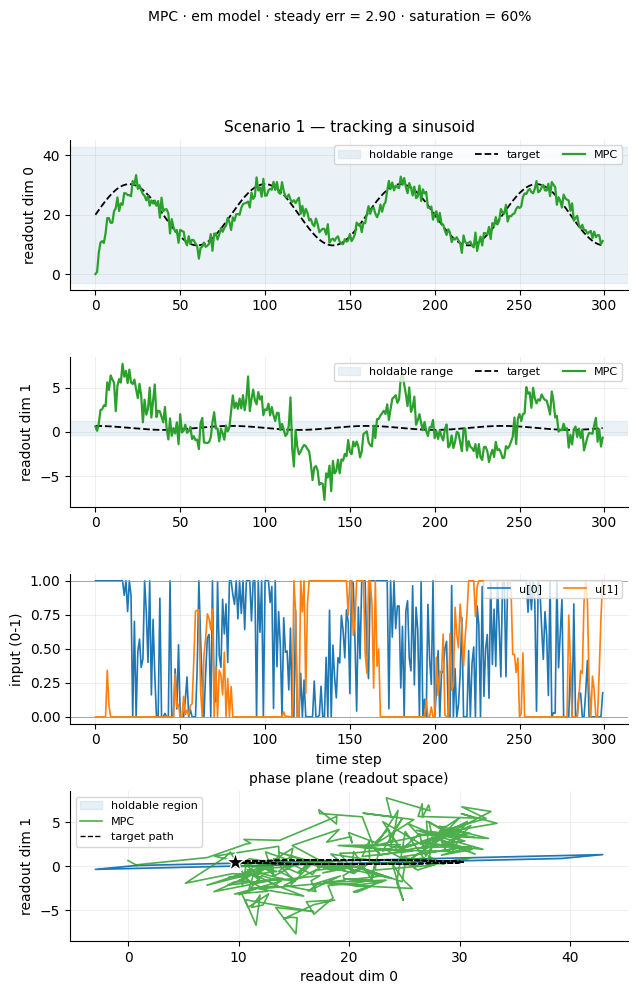

In [7]:
logs = run(MODEL, CONTROLLER, M, ref_sinusoid)
_ = plot_scenario(logs, M, ref_sinusoid,
                  "Scenario 1 — tracking a sinusoid", CONTROLLER)

## 7 · Scenario 2 — hold a feasible target

A level the one-sided actuator can reach. A good controller parks on the dashed
line and stays there.

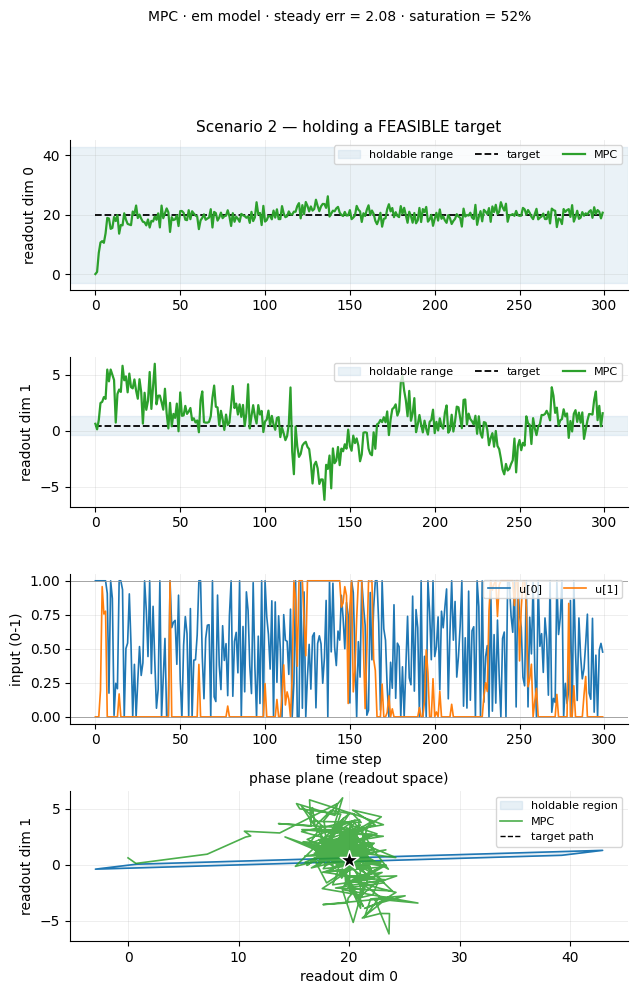

In [8]:
rf = ref_const(REF_FEASIBLE)
logs = run(MODEL, CONTROLLER, M, rf)
_ = plot_scenario(logs, M, rf,
                  "Scenario 2 — holding a FEASIBLE target", CONTROLLER)

## 8 · Scenario 3 — hold an infeasible target

The target sits outside the reachable set. The *right* behaviour is to push to
the edge and **saturate gracefully** (inputs pinned at 0/1) — not to wind up or
diverge. Watch the input panel.

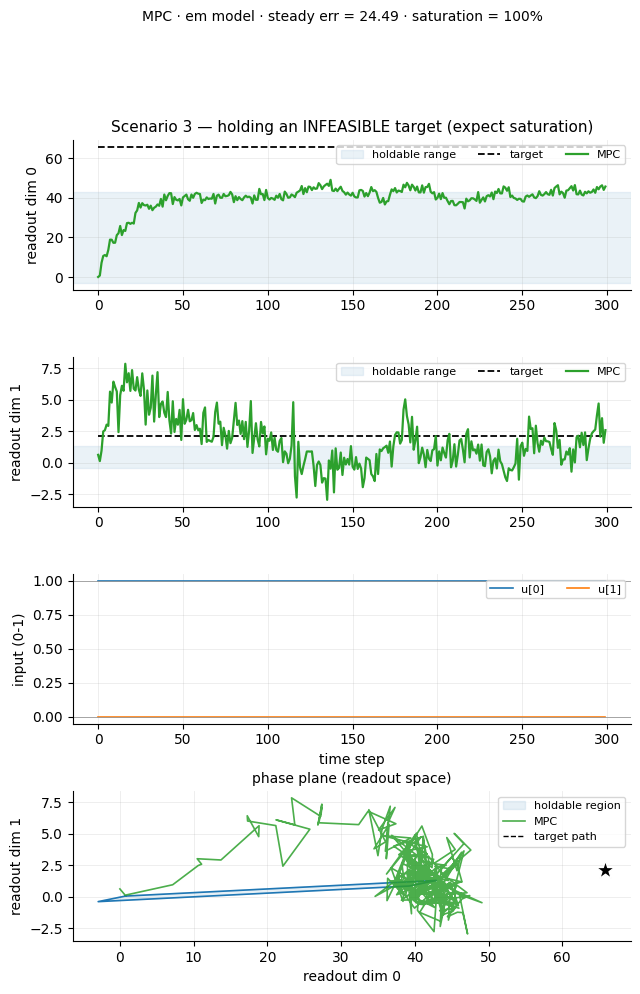

In [9]:
rf = ref_const(REF_INFEASIBLE)
logs = run(MODEL, CONTROLLER, M, rf)
_ = plot_scenario(logs, M, rf,
                  "Scenario 3 — holding an INFEASIBLE target (expect saturation)",
                  CONTROLLER)

## 9 · Scenario 4 — adapt to a moving target

The setpoint jumps to a new feasible point at `t = T_RUN/2` (dotted line). This
shows the transient response and how fast the controller re-settles.

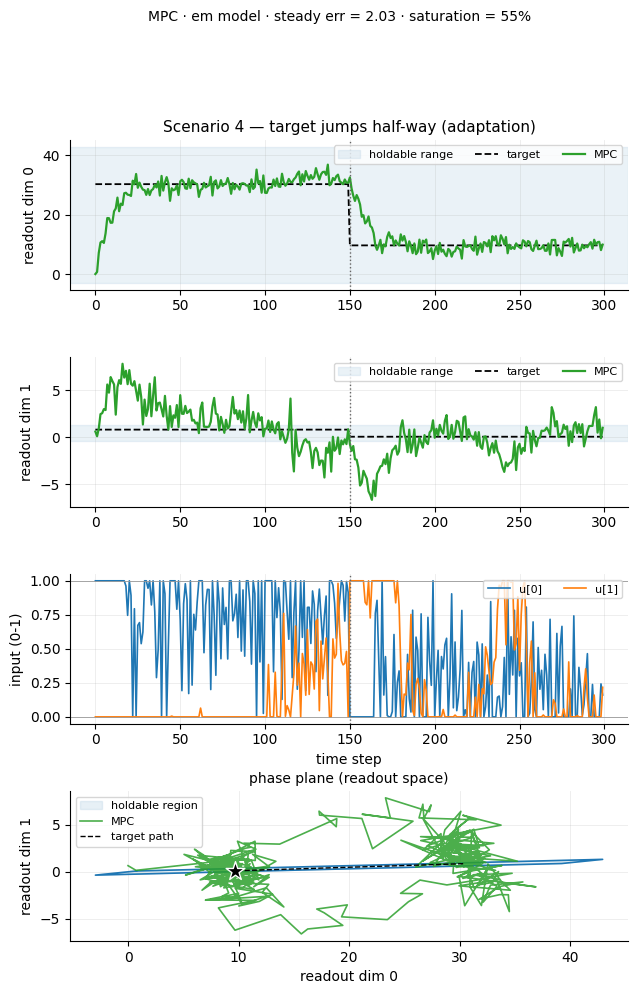

In [10]:
logs = run(MODEL, CONTROLLER, M, ref_moving)
_ = plot_scenario(logs, M, ref_moving,
                  "Scenario 4 — target jumps half-way (adaptation)",
                  CONTROLLER, switch=SWITCH)

## 10 · Compare several controllers at once

Overlay any list of controllers on one scenario. Edit `CONTROLLERS` and
`scenario` (any `ref_fn`) to taste.

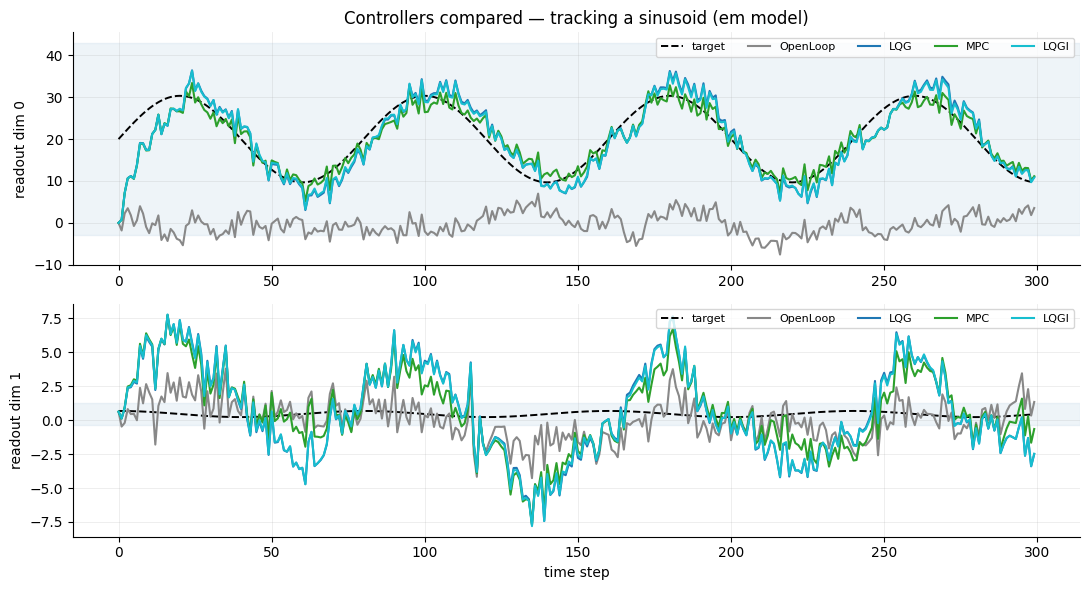

In [11]:
CONTROLLERS = ["OpenLoop", "LQG", "MPC", "LQGI"]
scenario_fn = ref_sinusoid          # try: ref_const(REF_FEASIBLE), ref_moving, ...
scenario_nm = "tracking a sinusoid"

R = ref_traj(scenario_fn, T_RUN)
t = np.arange(T_RUN)
qd = M.shape[0]
fig, axes = plt.subplots(qd, 1, figsize=(11, 3.0 * qd), squeeze=False)
for d in range(qd):
    ax = axes[d, 0]
    ax.axhspan(*feasible_interval(d), color="#a3c4dc", alpha=0.18)
    ax.plot(t, R[:, d], "--", color="black", lw=1.4, label="target")
    for name in CONTROLLERS:
        logs = run(MODEL, name, M, scenario_fn)
        z = logs["y"] @ M.T
        ax.plot(t, z[:, d], "-", color=ctrl_color(name), lw=1.5, label=name)
    ax.set_ylabel(f"readout dim {d}")
    if d == 0:
        ax.set_title(f"Controllers compared — {scenario_nm} ({ESTIMATOR} model)")
    ax.legend(fontsize=8, ncol=len(CONTROLLERS) + 1, loc="upper right")
    style_axis(ax)
axes[-1, 0].set_xlabel("time step")
plt.tight_layout(); plt.show()

## 11 · Compare estimators (true vs EM) for one controller

Same controller, same physical target — only the model inside the controller
changes. This is the cleanest "how much does identification error cost me?"
plot.

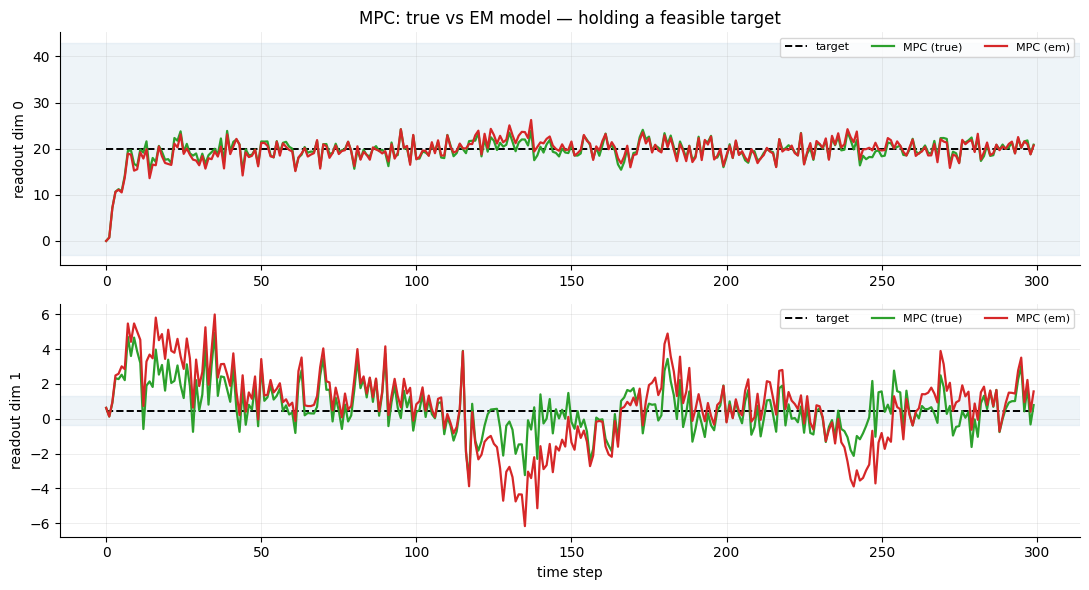

In [12]:
which_ctrl = CONTROLLER
scenario_fn = ref_const(REF_FEASIBLE)   # swap in any ref_fn
scenario_nm = "holding a feasible target"

R = ref_traj(scenario_fn, T_RUN)
t = np.arange(T_RUN)
qd = M.shape[0]
styles = {"true": ("-", "#2ca02c"), "em": ("-", "#d62728")}
fig, axes = plt.subplots(qd, 1, figsize=(11, 3.0 * qd), squeeze=False)
for d in range(qd):
    ax = axes[d, 0]
    ax.axhspan(*feasible_interval(d), color="#a3c4dc", alpha=0.18)
    ax.plot(t, R[:, d], "--", color="black", lw=1.4, label="target")
    for est_name in ("true", "em"):
        logs = run(build_model(est_name), which_ctrl, M, scenario_fn)
        z = logs["y"] @ M.T
        ls, col = styles[est_name]
        ax.plot(t, z[:, d], ls, color=col, lw=1.6, label=f"{which_ctrl} ({est_name})")
    ax.set_ylabel(f"readout dim {d}")
    if d == 0:
        ax.set_title(f"{which_ctrl}: true vs EM model — {scenario_nm}")
    ax.legend(fontsize=8, ncol=3, loc="upper right")
    style_axis(ax)
axes[-1, 0].set_xlabel("time step")
plt.tight_layout(); plt.show()

## 12 · General overlay — mix any controllers & estimators

List any combination of `(controller, estimator)` pairs in `SPECS` and overlay
them all on one scenario. Each curve gets its own colour; the legend reads
`controller (estimator)`. Works for both readouts (the 2-D readout also gets a
phase-plane overlay).

Swap `scenario_fn` for any reference: `ref_sinusoid`, `ref_const(REF_FEASIBLE)`,
`ref_const(REF_INFEASIBLE)`, or `ref_moving` (pass `switch=SWITCH`).

C:\Users\sassa\AppData\Local\Temp\ipykernel_9800\499011988.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  palette = cm.get_cmap("tab10")
C:\Users\sassa\AppData\Local\Temp\ipykernel_9800\499011988.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


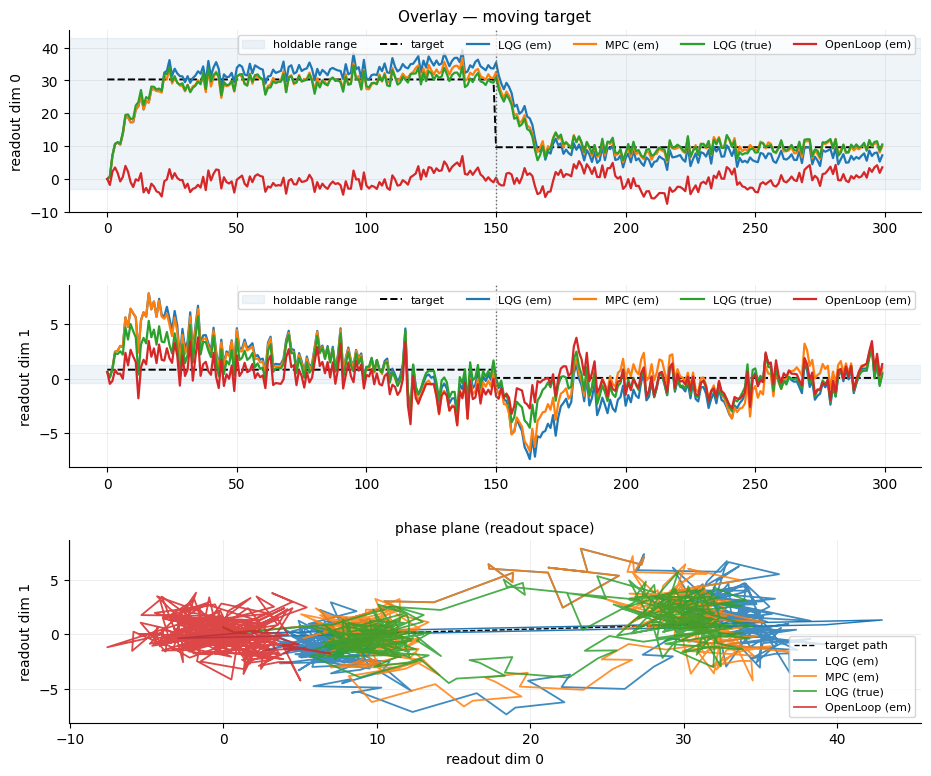

steady-state error (last third):
  LQG (em)                     3.399
  MPC (em)                     2.034
  LQG (true)                   1.835
  OpenLoop (em)                10.502


In [13]:
import matplotlib.cm as cm

def overlay_runs(specs, ref_fn, title, switch=None, shade_feasible=True):
    """specs: list of (controller_name, estimator) e.g. [("LQG","em"),("MPC","true")]."""
    T = T_RUN
    R = ref_traj(ref_fn, T)
    t = np.arange(T)
    qd = M.shape[0]
    palette = cm.get_cmap("tab10")
    runs = []
    for i, (name, est) in enumerate(specs):
        logs = run(build_model(est), name, M, ref_fn)
        z = logs["y"] @ M.T
        col = palette(i % 10)
        runs.append((f"{name} ({est})", z, logs["u"], col))

    n_panels = qd + (1 if qd == 2 else 0)
    fig = plt.figure(figsize=(11, 3.0 * n_panels))
    gs = fig.add_gridspec(n_panels, 1, hspace=0.4)

    for d in range(qd):
        ax = fig.add_subplot(gs[d, 0])
        if shade_feasible:
            ax.axhspan(*feasible_interval(d), color="#a3c4dc", alpha=0.18,
                       label="holdable range")
        ax.plot(t, R[:, d], "--", color="black", lw=1.4, label="target")
        for label, z, _u, col in runs:
            ax.plot(t, z[:, d], "-", color=col, lw=1.6, label=label)
        if switch is not None:
            ax.axvline(switch, color="0.4", ls=":", lw=1.0)
        ax.set_ylabel(f"readout dim {d}")
        ax.legend(fontsize=8, ncol=len(runs) + 2, loc="upper right")
        style_axis(ax)
        if d == 0:
            ax.set_title(title, fontsize=11)

    if qd == 2:
        axp = fig.add_subplot(gs[qd, 0])
        poly = V[[0, 1, 3, 2, 0]]
        axp.fill(poly[:, 0], poly[:, 1], color="#a3c4dc", alpha=0.22)
        axp.plot(poly[:, 0], poly[:, 1], color="#1f77b4", lw=1.0)
        axp.plot(R[:, 0], R[:, 1], "--", color="black", lw=1.0, label="target path")
        for label, z, _u, col in runs:
            axp.plot(z[:, 0], z[:, 1], "-", color=col, lw=1.3, alpha=0.85, label=label)
        axp.set_xlabel("readout dim 0"); axp.set_ylabel("readout dim 1")
        axp.set_title("phase plane (readout space)", fontsize=10)
        axp.legend(fontsize=8); style_axis(axp)

    plt.tight_layout(); plt.show()

    tail = max(1, T // 3)
    print("steady-state error (last third):")
    for label, z, _u, _c in runs:
        ss = float(np.mean(np.linalg.norm((z - R)[-tail:], axis=-1)))
        print(f"  {label:28s} {ss:.3f}")


# ---- edit these two lines -------------------------------------------------
SPECS = [("LQG", "em"), ("MPC", "em"), ("LQG", "true"), ("OpenLoop", "em")]
# scenario_fn, scenario_nm, sw = ref_sinusoid, "tracking a sinusoid", None
scenario_fn, scenario_nm, sw = ref_moving, "moving target", SWITCH
# ---------------------------------------------------------------------------

overlay_runs(SPECS, scenario_fn, f"Overlay — {scenario_nm}", switch=sw)